## Задача 4. Энтропия и информационное содержание

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#кусок кода из задачи 1 для подсчета ppm

sites = ["GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA", "ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC", "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC",
         "CAGGTTGGC"]
ncltd = ['A', 'T', 'G', 'C']

def pfm(sites, nucleotids):
    seq_length = len(sites[0]) #находим длину последовательности - просто возьмем длину нулевой - они все одинаковые
    n_sites = len(sites) #находим количество последовательностей всего - чтобы дальше для каждой посчитать 
    
    pfm_matrix = np.zeros((4, seq_length), dtype=int) #создаем матрицу необходимый размеров 4*n
    for i in range(seq_length):
        for nuc_indx, nuc in enumerate(nucleotids):
            count = 0 
            for site in sites:
                if site[i] == nuc:
                    count += 1
            pfm_matrix[nuc_indx][i] = count
    return pfm_matrix, ncltd

def pfm_to_ppm(pfm_matrix, alpha):
    total_sites = np.sum(pfm_matrix[:, 0]) 
    num_ncltd, seq_length = pfm_matrix.shape
    ppm_matrix = np.zeros((4, seq_length), dtype=float)
    for i in range (num_ncltd):
        for j in range(seq_length):
            ppm_matrix[i][j] = (pfm_matrix[i][j] + alpha)/(total_sites + 4 * alpha)
    return ppm_matrix

pfm_result, nucleotides = pfm(sites, ncltd)
ppm = pfm_to_ppm(pfm_result, 0.1)

In [9]:
#считаем энтропию Шеннона по формуле H(i) = -sum(p_b_i * log2(p_b_i))
H = np.zeros(9)
for i in range(9):
    for b in range(4):
        if ppm[b, i] > 0:
            H[i] -= ppm[b, i] * np.log2(ppm[b, i])
print(H)

[1.60312107 0.87576168 1.03086909 0.23429203 0.23429203 1.44801367
 1.02532307 0.87576168 1.03086909]


In [10]:
IC = 2 - H
print(IC)

[0.39687893 1.12423832 0.96913091 1.76570797 1.76570797 0.55198633
 0.97467693 1.12423832 0.96913091]


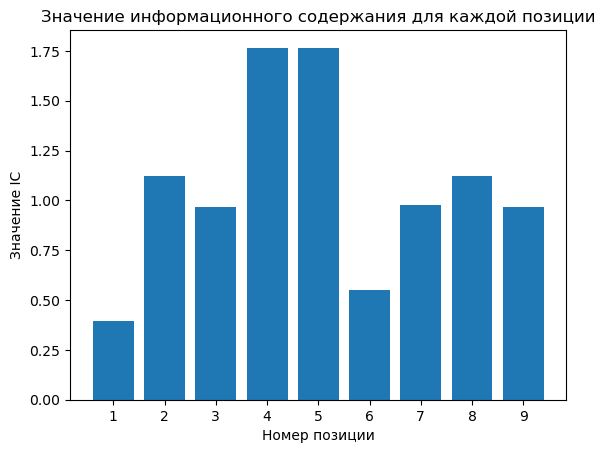

In [15]:
positions = [i for i in range (1,10)]
plt.bar(positions, IC)
plt.title('Значение информационного содержания для каждой позиции')
plt.xlabel('Номер позиции')
plt.ylabel('Значение IC')
plt.xticks(positions)
plt.show()

In [16]:
#посмотрим какая буква встречается в конкретной позиции чаще остальных, чтобы сделать вывод о кор-мотиве
for i in range(9):
    dominant = ncltd[np.argmax(ppm[:, i])]
    print(f"Позиция {i+1}: доминирует {dominant}, IC = {IC[i]:.3f}")

Позиция 1: доминирует C, IC = 0.397
Позиция 2: доминирует A, IC = 1.124
Позиция 3: доминирует G, IC = 0.969
Позиция 4: доминирует G, IC = 1.766
Позиция 5: доминирует T, IC = 1.766
Позиция 6: доминирует C, IC = 0.552
Позиция 7: доминирует A, IC = 0.975
Позиция 8: доминирует G, IC = 1.124
Позиция 9: доминирует C, IC = 0.969


In [17]:
for i in range(len(sites)):
    print(sites[i])

GAGGTAAAC
TCCGTAAGC
CAGGTTGGA
ACAGTCAGC
TAGGTCAGC
CAGGTCAGC
CAGGTCGAT
CAGGTCAGC
CAGGTCAGC
CAGGTTGGC


# Вывод
По предварительному анализу (визуальному осмотру последовательностей) видно, что "кор-мотивами" являются нуклеотиды G и Т в позициях 4, 5 - они одинаковы во всех девяти представленных сайтах связывания. Также видно, что в позициях 2 и 8 совсем небольшие вариации - вероятно это тоже важные для связывания позиции. Остальные, в целом, допускают вариации.

Визуальный осмотр полностью согласуется с выводами, полученными в ходе решения - видим, что для позиций 4 и 5 максимальное значение IC (информационного содержания), далее идут позиции 2 и 8. Остальные позиции имеют меньшее значение IC.